# Run postprocessing


In [107]:
import pandas as pd

output_directory = "../output"
run_directory = "run_2026_07_22__14_27_11"

episodes = pd.read_csv(f"{output_directory}/{run_directory}/episodes.csv")

# reference: 64x64, gamma 0.99, lr: 0.0005/0.001, no target network

episodes

,index,episode_time,steps,noise,episode_reward,avg_critic_loss,avg_actor_loss
0,0,2.499998,150,0,23.803637,0.000000,0.000000
1,1,2.349998,141,0,15.608380,0.284871,0.001329
2,2,2.183332,131,0,17.400430,0.269458,-0.049350
3,3,1.549999,93,0,16.922712,0.246477,-0.093278
4,4,1.399999,84,0,12.035816,0.217371,-0.152115
...,...,...,...,...,...,...,...
406,406,15.016609,901,0,2290.350000,0.727836,-165.554430
407,407,15.016609,901,0,2340.845500,0.758883,-169.760850
408,408,15.016609,901,0,2399.465600,0.779217,-173.745620
409,409,15.016609,901,0,2380.942600,0.806278,-177.726350


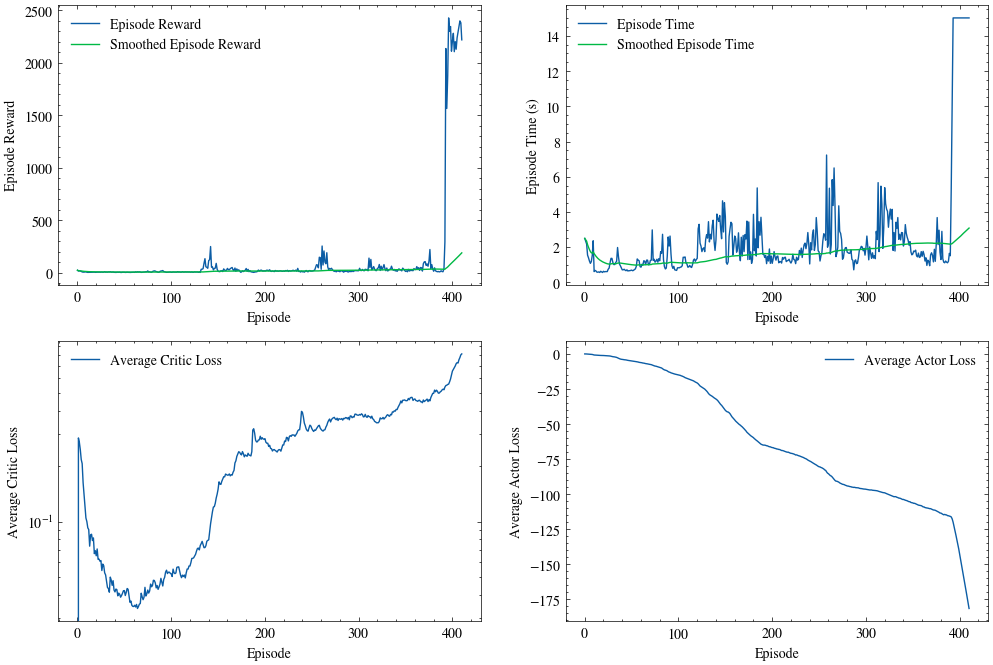

In [108]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(episodes["index"], episodes["episode_reward"], label="Episode Reward")
plt.plot(
    episodes["index"],
    episodes["episode_reward"].rolling(window=250, min_periods=1).mean(),
    label="Smoothed Episode Reward",
)
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(episodes["index"], episodes["episode_time"], label="Episode Time")
plt.plot(
    episodes["index"],
    episodes["episode_time"].rolling(window=250, min_periods=1).mean(),
    label="Smoothed Episode Time",
)
plt.xlabel("Episode")
plt.ylabel("Episode Time (s)")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(episodes["index"], episodes["avg_critic_loss"], label="Average Critic Loss")
plt.xlabel("Episode")
plt.ylabel("Average Critic Loss")
plt.yscale("log")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(episodes["index"], episodes["avg_actor_loss"], label="Average Actor Loss")
plt.xlabel("Episode")
plt.ylabel("Average Actor Loss")
plt.legend()

plt.show()